### BAB 1: Data Loading & Initial Understanding

**Tujuan:** Memuat dataset dan memahami struktur awal sebelum pembersihan.

In [1]:
# Mengimport library yang dibutuhkan dan memuat dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

data_raw = pd.read_csv("Student Performance Factors.csv")
data_raw.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
# Menampilkan informasi umum dataset untuk melihat jumlah baris, kolom, dan tipe data
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [3]:
# Menampilkan statistik deskriptif dari dataset
data_raw.describe(include="all")

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


In [4]:
# Mengambil dan menampilkan jumlah kolom numerik dan kategorikal
numeric_features = data_raw.select_dtypes(include=['number']).columns
kategorical_features = data_raw.select_dtypes(include=['str']).columns

# Kolom numerik untuk scaling (tanpa target Exam_Score)
numeric_features_scaled = [c for c in numeric_features if c != 'Exam_Score']
print("Kolom Numerik:", list(numeric_features))
print("Kolom Kategorikal:", list(kategorical_features))
print("Kolom Numerik Scaled:", list(numeric_features_scaled))

Kolom Numerik: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Kolom Kategorikal: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Kolom Numerik Scaled: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


In [5]:
# Membuat salinan data mentah untuk diproses
df = data_raw.copy()

In [6]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

### BAB 2: Data Cleaning

**Tujuan:** Menangani data yang hilang dan duplikat sebelum EDA. Pada dataset ini missing tidak banyak, jadi tidak perlu di-drop (akan menghilangkan 234 baris jika digabung). Akan ditangani nanti di dalam pipeline agar tidak terjadi data leakage.

In [7]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()

print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [Hours_Studied, Attendance, Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Sleep_Hours, Previous_Scores, Motivation_Level, Internet_Access, Tutoring_Sessions, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Physical_Activity, Learning_Disabilities, Parental_Education_Level, Distance_from_Home, Gender, Exam_Score]
Index: []


### BAB 3: EDA - Analisis Outlier dan Distribusi

**Tujuan:** Melihat sebaran data dan bentuk distribusinya. Ini menentukan apakah kita butuh StandardScaler atau MinMaxScaler, dan fitur mana yang normal.

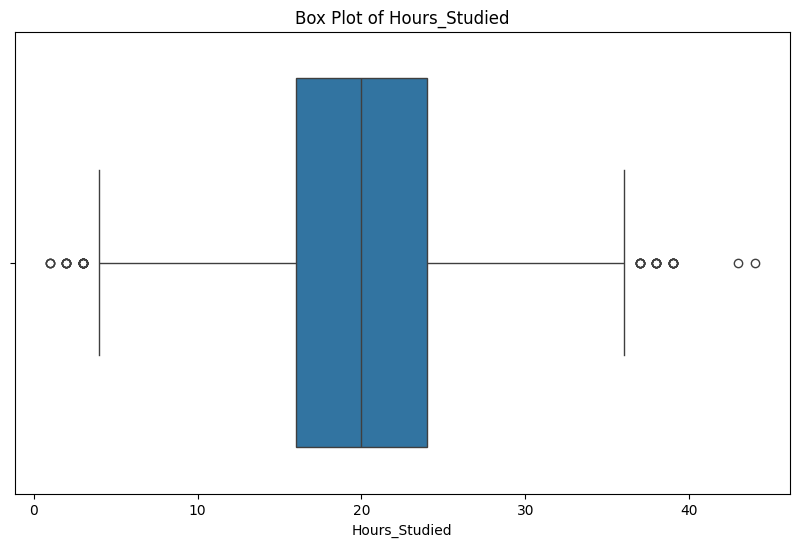

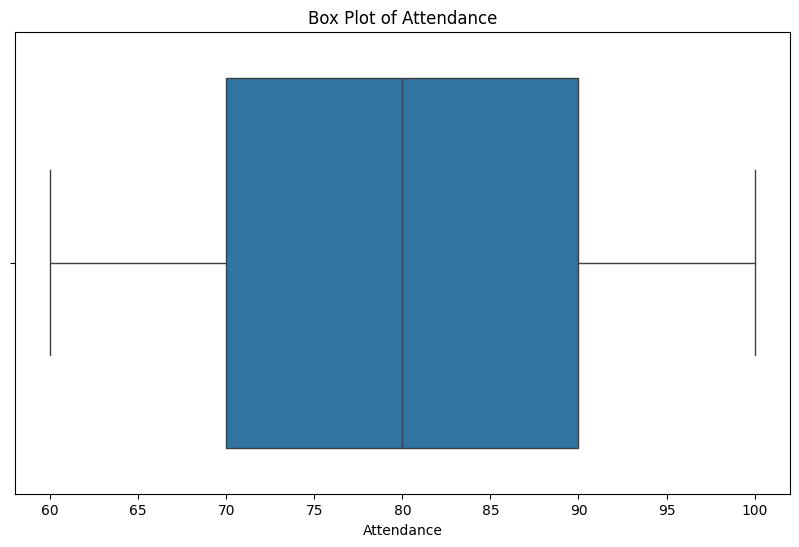

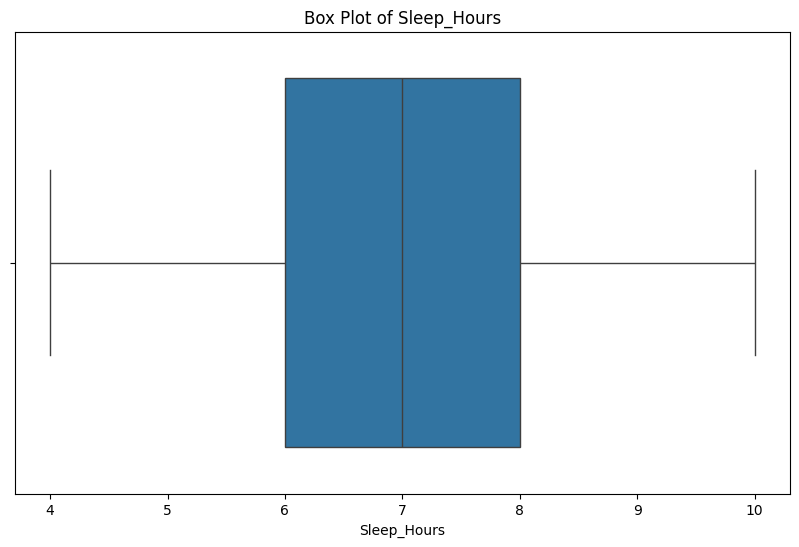

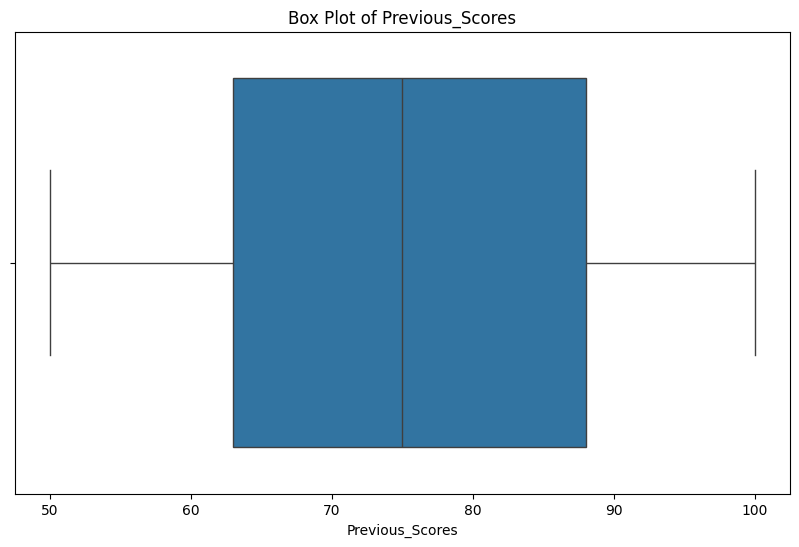

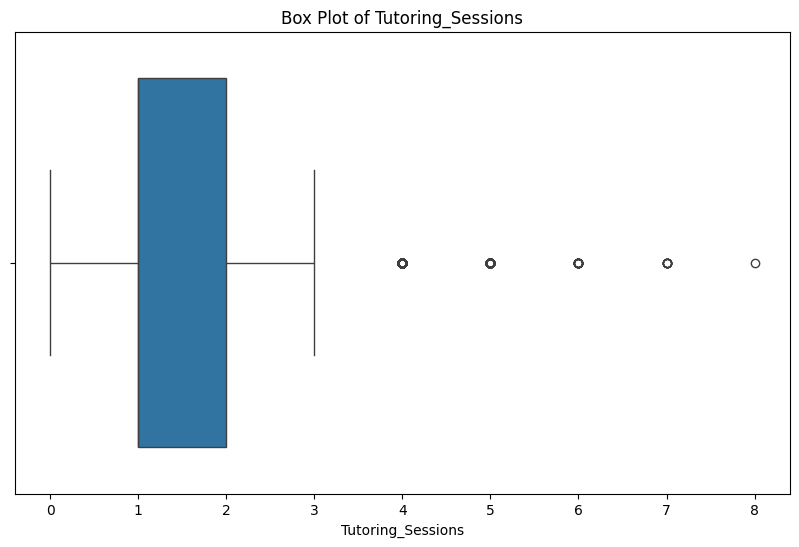

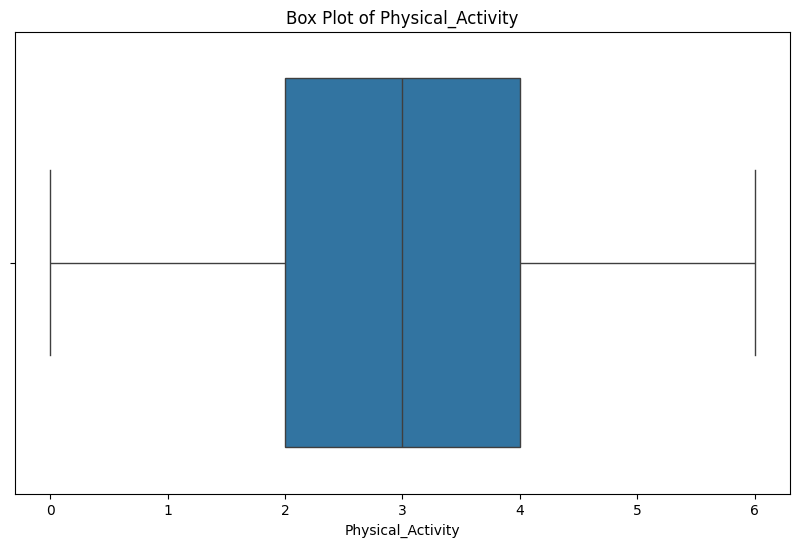

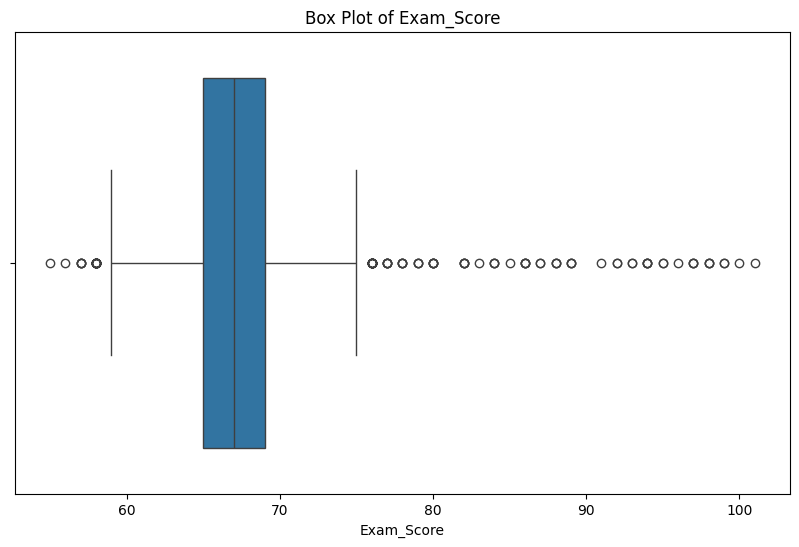

In [8]:
# Menampilkan grafik box plot untuk mendeteksi outliers
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [9]:
# Mengidentifikasi outliers menggunakan IQR
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Hitung batas bawah & atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print("Batas Bawah:\n", batas_bawah)
print("\nBatas Atas:\n", batas_atas)

# Cek berapa outlier di tiap kolom
outliers = ((df[numeric_features] < batas_bawah) | (df[numeric_features] > batas_atas)).sum()
print("\nJumlah Outlier:\n", outliers)

Batas Bawah:
 Hours_Studied         4.0
Attendance           40.0
Sleep_Hours           3.0
Previous_Scores      25.5
Tutoring_Sessions    -0.5
Physical_Activity    -1.0
Exam_Score           59.0
dtype: float64

Batas Atas:
 Hours_Studied         36.0
Attendance           120.0
Sleep_Hours           11.0
Previous_Scores      125.5
Tutoring_Sessions      3.5
Physical_Activity      7.0
Exam_Score            75.0
dtype: float64

Jumlah Outlier:
 Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64


In [10]:
# Menampilkan jumlah frekuensi data yang urut berdasarkan nilai indeksnya
df_exam = df["Exam_Score"].value_counts().sort_index().reset_index()
df_exam.columns = ["Exam_Score", "Count"]
df_tutoring = df["Tutoring_Sessions"].value_counts().sort_index().reset_index()
df_tutoring.columns = ["Tutoring_Sessions", "Count"]
df_hours = df["Hours_Studied"].value_counts().sort_index().reset_index()
df_hours.columns = ["Hours_Studied", "Count"]

df_frequency_summary = pd.concat([df_exam, df_tutoring, df_hours], axis=1)
df_frequency_summary = df_frequency_summary.fillna("-")
print(df_frequency_summary)

    Exam_Score  Count Tutoring_Sessions   Count Hours_Studied  Count
0           55      1               0.0  1513.0           1.0    3.0
1           56      1               1.0  2179.0           2.0    6.0
2           57      4               2.0  1649.0           3.0   12.0
3           58     22               3.0   836.0           4.0   17.0
4           59     40               4.0   301.0           5.0   21.0
5           60     77               5.0   103.0           6.0   17.0
6           61    171               6.0    18.0           7.0   51.0
7           62    264               7.0     7.0           8.0   58.0
8           63    371               8.0     1.0           9.0   86.0
9           64    501                 -       -          10.0   94.0
10          65    679                 -       -          11.0  146.0
11          66    751                 -       -          12.0  192.0
12          67    717                 -       -          13.0  218.0
13          68    759             

Text(0.5, 1.0, 'Histogram Sebelum Standardisasi')

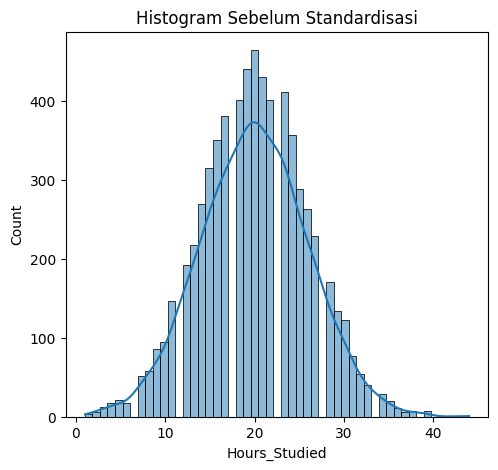

In [11]:
# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data_raw[numeric_features[0]], kde=True)
plt.title("Histogram Sebelum Standardisasi")

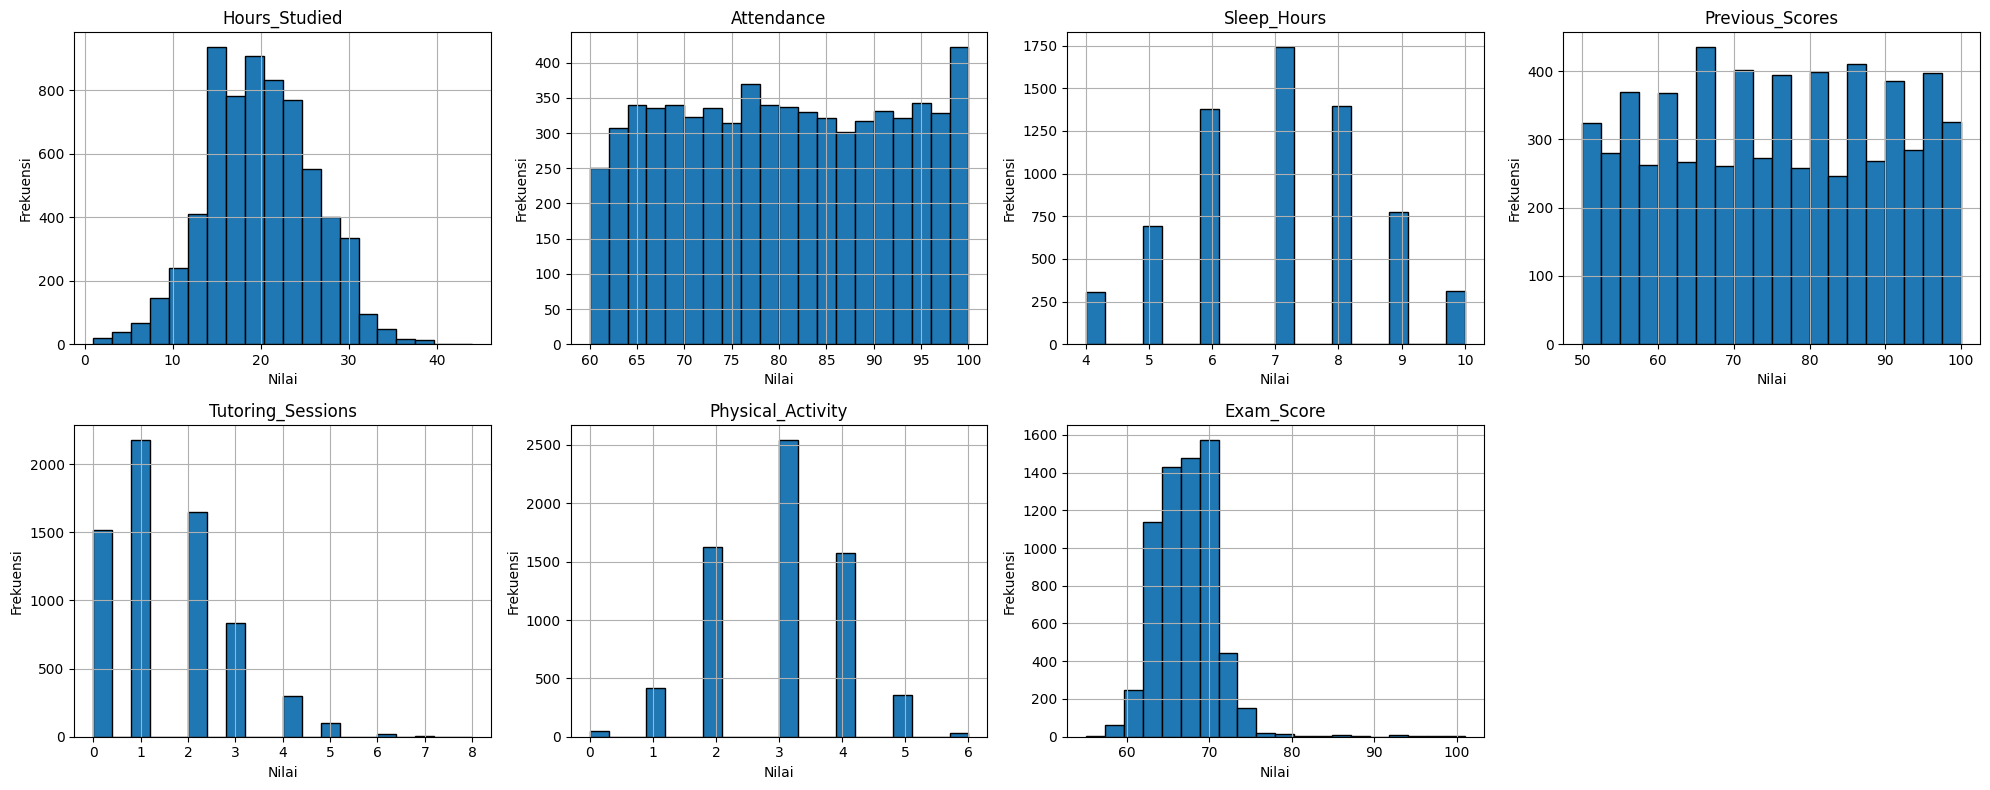

In [12]:
# Menampilkan histogram semua kolom numerik untuk melihat sebaran data
num_vars = len(numeric_features)
n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(numeric_features):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Menghapus subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

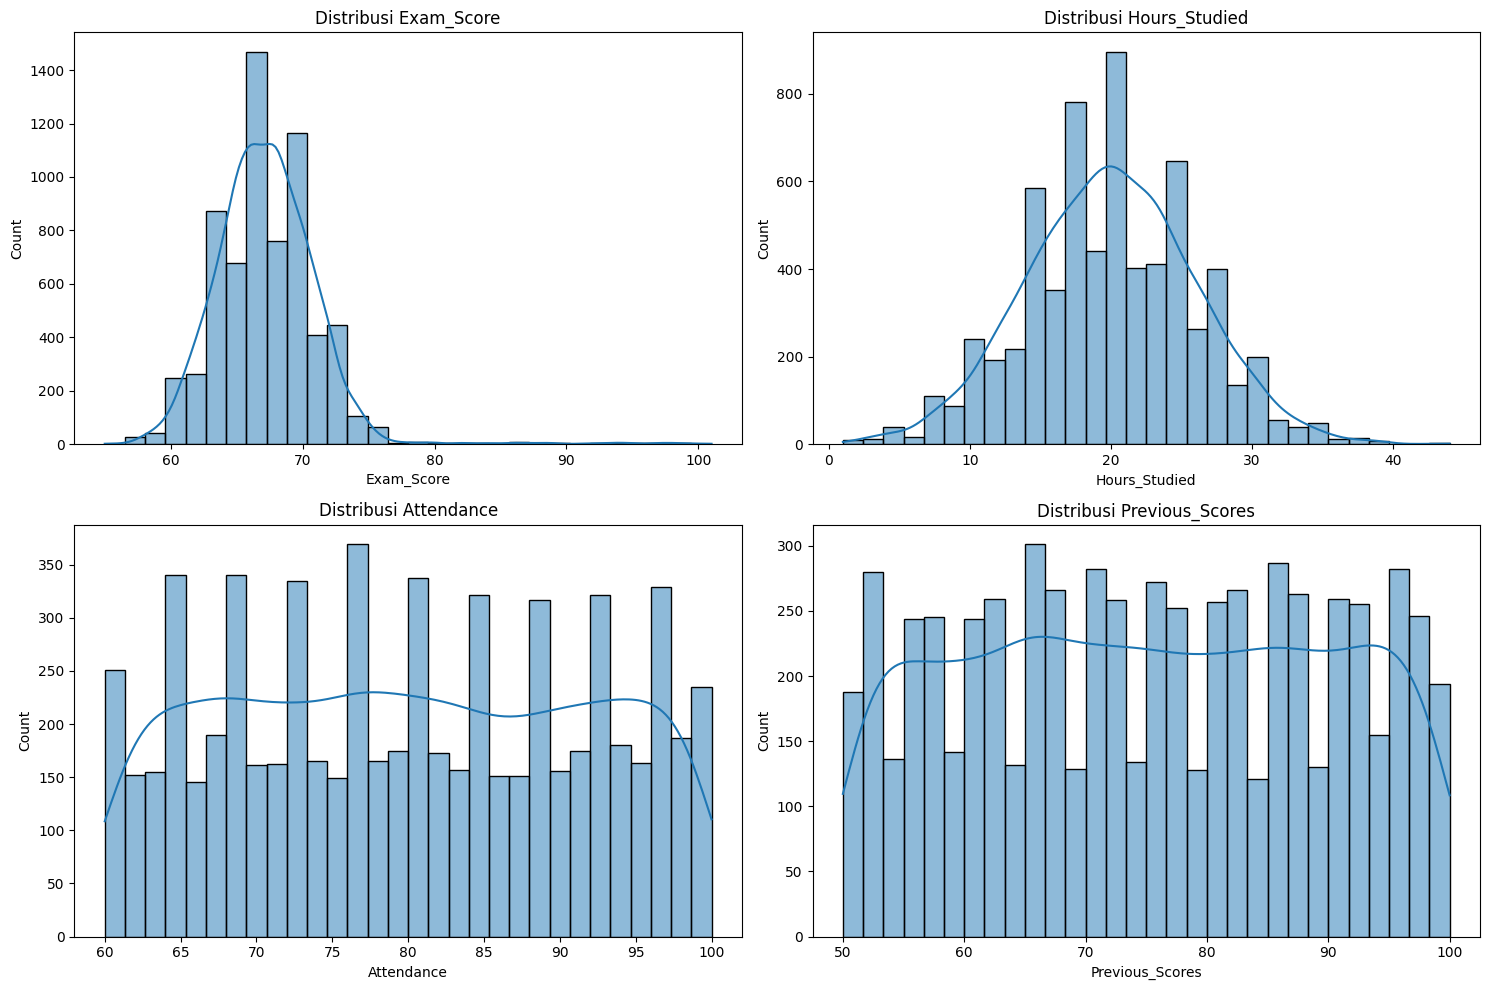

In [13]:
# Menampilkan distribusi beberapa kolom penting beserta garis KDE
selected_columns = ['Exam_Score', 'Hours_Studied', 'Attendance', 'Previous_Scores']

plt.figure(figsize=(15, 10))
for i, column in enumerate(selected_columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribusi {column}')

plt.tight_layout()
plt.show()

### BAB 4: ExDA - Analisis Korelasi

**Tujuan:** Melihat hubungan antar fitur numerik dan hubungan fitur terhadap target `Exam_Score`. Ini menentukan model apa yang cocok.

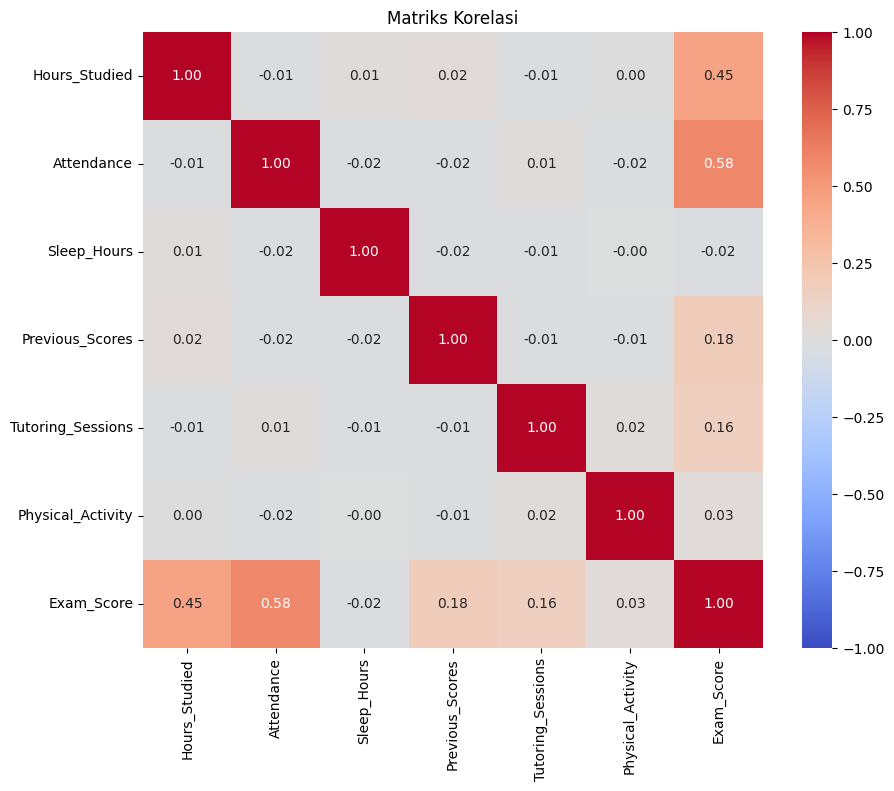

In [14]:
# Menampilkan matriks korelasi antar kolom numerik
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)
plt.title('Matriks Korelasi')
plt.show()

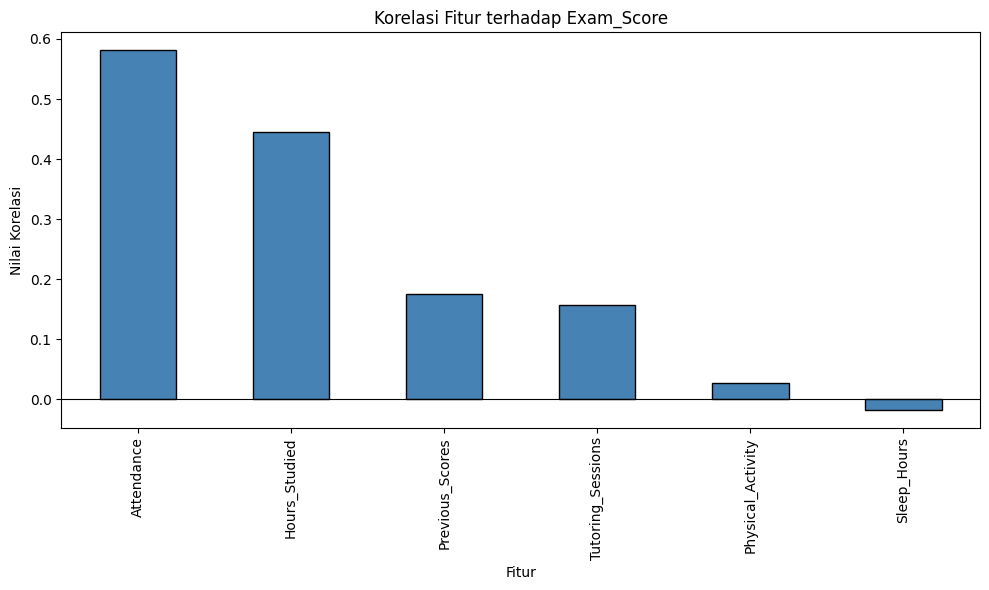

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [15]:
# Menghitung korelasi setiap fitur numerik terhadap target Exam_Score
target_correlation = df[numeric_features].corr()['Exam_Score']
target_correlation = target_correlation.drop('Exam_Score').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_correlation.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Korelasi Fitur terhadap Exam_Score')
plt.xlabel('Fitur')
plt.ylabel('Nilai Korelasi')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_correlation)

### BAB 5: Data Preparation - Splitting & Preprocessing Pipeline

**Tujuan:** Memisahkan fitur dan target, membagi train-test, dan membuat pipeline preprocessing yang aman dari data leakage.

In [16]:
# Memisahkan fitur (X) dan target (y)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

In [17]:
# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data: {len(X)}")
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data: 6607
Jumlah data latih: 5285
Jumlah data uji: 1322


In [18]:
# Mendefinisikan kolom berdasarkan jenis encoding-nya
numeric_cols = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours',
    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

ordinal_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
    'Family_Income', 'Teacher_Quality', 'Parental_Education_Level',
    'Distance_from_Home'
]

ordinal_categories = [
    ['Low', 'Medium', 'High'],                       # Parental_Involvement
    ['Low', 'Medium', 'High'],                       # Access_to_Resources
    ['Low', 'Medium', 'High'],                       # Motivation_Level
    ['Low', 'Medium', 'High'],                       # Family_Income
    ['Low', 'Medium', 'High'],                       # Teacher_Quality
    ['High School', 'College', 'Postgraduate'],      # Parental_Education_Level
    ['Near', 'Moderate', 'Far'],                     # Distance_from_Home
]

nominal_cols = [
    'Extracurricular_Activities', 'Internet_Access', 'School_Type',
    'Learning_Disabilities', 'Gender', 'Peer_Influence'
]

In [19]:
# Preprocessor untuk model linear (Ridge)
preprocessor_linear = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
    ]), numeric_cols),

    ('ord', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(categories=ordinal_categories)),
    ]), ordinal_cols),

    ('nom', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ]), nominal_cols),
])

In [20]:
# Preprocessor untuk model tree (RandomForestRegressor & GradientBoostingRegressor)
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_cols),

    ('ord', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(categories=ordinal_categories)),
    ]), ordinal_cols),

    ('nom', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ]), nominal_cols),
])

### BAB 6: Modeling - Training 3 Algoritma

**Tujuan:** Melatih 3 model dengan pendekatan berbeda untuk dibandingkan. 1 linear (Ridge) dan 2 tree-based (Random Forest & Gradient Boosting).

In [21]:
# Ridge Regression
pipe_ridge = Pipeline(steps=[
    ('prep', preprocessor_linear),
    ('reg', Ridge(alpha=1.0, random_state=42)),
])

# Random Forest Regressor
pipe_rf = Pipeline(steps=[
    ('prep', preprocessor_tree),
    ('reg', RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

# Gradient Boosting Regressor
pipe_gb = Pipeline(steps=[
    ('prep', preprocessor_tree),
    ('reg', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
    )),
])

# Melatih model Ridge Regression, Random Forest, dan Gradient Boosting menggunakan data training
pipe_ridge.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [22]:
# Inisialisasi/definisi dictionary untuk menyimpan pipeline model
models = {
    'Ridge'             : pipe_ridge,
    'RandomForest'      : pipe_rf,
    'GradientBoosting'  : pipe_gb,
}

### BAB 7: Validasi Transformasi & Evaluasi Model

**Tujuan:** Memvalidasi bahwa standardisasi dari pipeline sudah benar, menghitung metric MAE, RMSE, R2, visualisasi performa, dan melihat fitur yang paling penting.

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

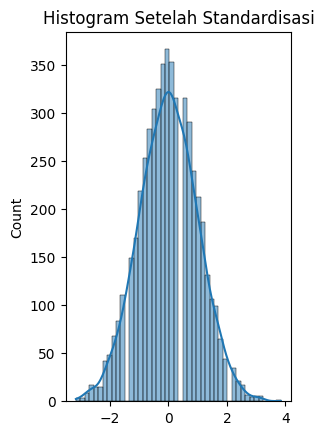

In [23]:
# Histogram Setelah Standardisasi (dari pipeline)
num_pipe = pipe_ridge.named_steps['prep'].named_transformers_['num']
X_train_num_scaled = num_pipe.transform(X_train[numeric_cols])

plt.subplot(1, 2, 2)
sns.histplot(X_train_num_scaled[:, 0], kde=True)   # kolom Hours_Studied
plt.title("Histogram Setelah Standardisasi")

In [24]:
# Membuat DataFrame dari hasil scale, kolom sesuai urutan numeric_cols
X_train_scaled_df = pd.DataFrame(X_train_num_scaled, columns=numeric_cols, index=X_train.index)

train_exam = y_train.value_counts().sort_index().reset_index()
train_exam.columns = ["Exam_Score", "Count"]
train_tutoring = X_train_scaled_df["Tutoring_Sessions"].value_counts().sort_index().reset_index()
train_tutoring.columns = ["Tutoring_Sessions", "Count"]
train_hours = X_train_scaled_df["Hours_Studied"].value_counts().sort_index().reset_index()
train_hours.columns = ["Hours_Studied", "Count"]

train_frequency_summary = pd.concat([train_exam, train_tutoring, train_hours], axis=1)
train_frequency_summary = train_frequency_summary.fillna("-")
print(train_frequency_summary)

    Exam_Score  Count Tutoring_Sessions   Count Hours_Studied  Count
0           56      1         -1.215819  1203.0     -3.165022    3.0
1           57      2         -0.405017  1737.0     -2.998153    3.0
2           58     19          0.405784  1329.0     -2.831284    9.0
3           59     35          1.216586   667.0     -2.664414   17.0
4           60     64          2.027388   249.0     -2.497545   15.0
5           61    145           2.83819    76.0     -2.330676   15.0
6           62    210          3.648992    16.0     -2.163807   42.0
7           63    294          4.459794     7.0     -1.996937   48.0
8           64    407          5.270596     1.0     -1.830068   68.0
9           65    531                 -       -     -1.663199   83.0
10          66    607                 -       -      -1.49633  111.0
11          67    575                 -       -      -1.32946  149.0
12          68    612                 -       -     -1.162591  170.0
13          69    506             

In [25]:
# Menghitung metric evaluasi (MAE, RMSE, R2) & menyimpannya ke dalam DataFrame yang diurutkan berdasarkan nilai RMSE terkecil
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Ridge,0.445644,1.800148,0.770745
1,GradientBoosting,0.699701,1.918946,0.739488
2,RandomForest,1.044667,2.105452,0.686388


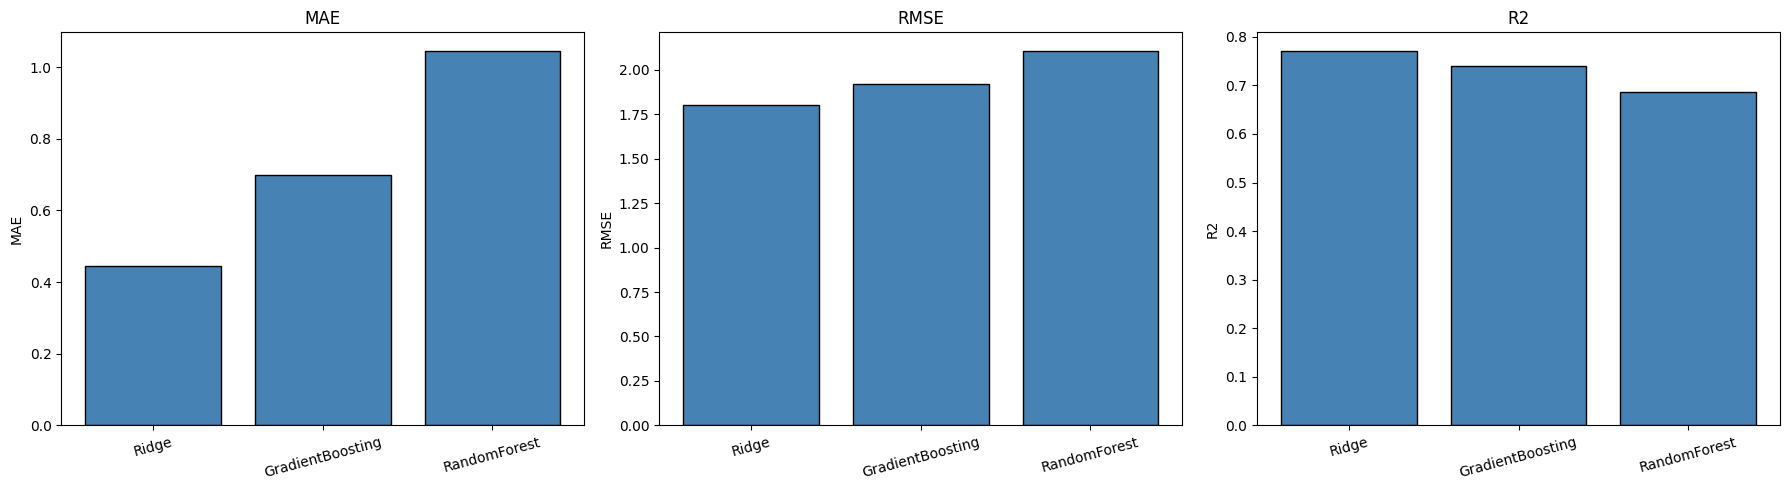

In [26]:
# Menampilkan grafik perbandingan antara nilai aktual dan hasil prediksi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(results_df['Model'], results_df[metric], color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

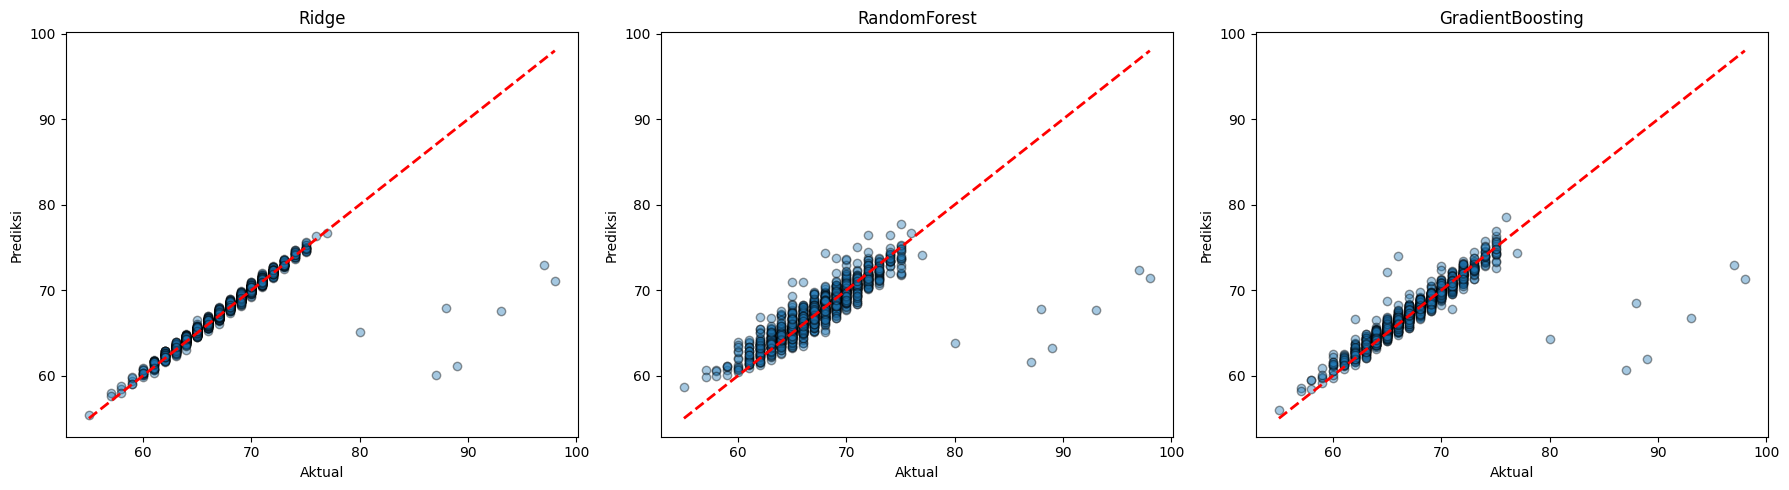

In [27]:
# Menampilkan grafik residual secara berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='k')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2)

    ax.set_title(name)
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')

plt.tight_layout()
plt.show()

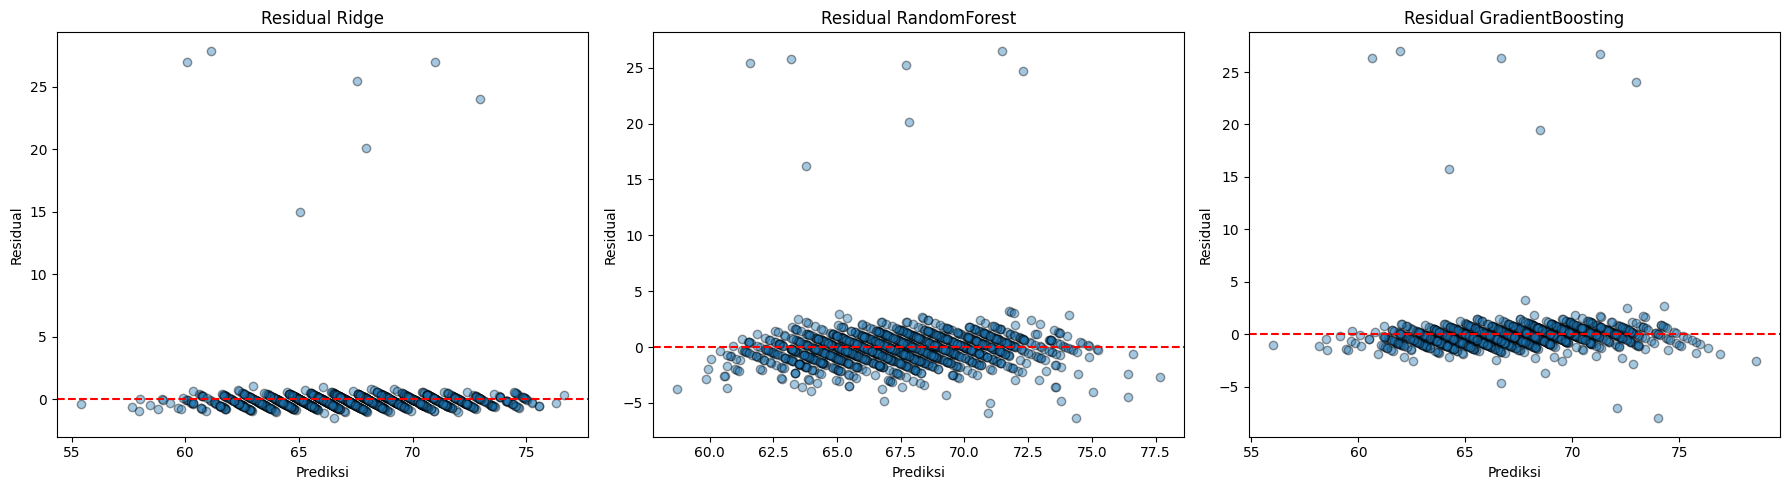

In [28]:
# Menampilkan grafik residual secara berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.4, edgecolors='k')
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Residual {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

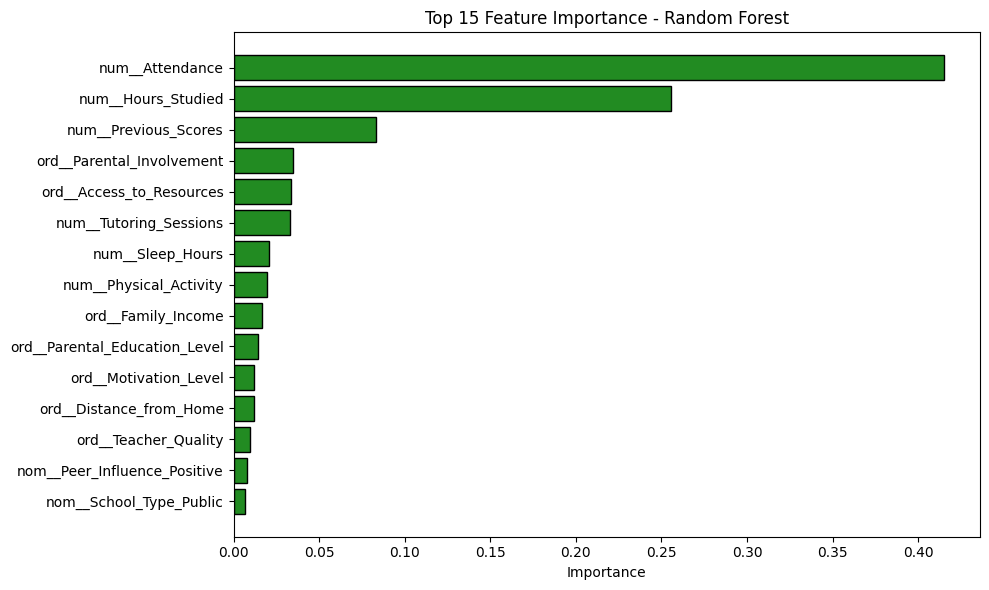

In [29]:
# Mengurutkan dan menampilkan 15 fitur paling berpengaruh dalam model Random Forest
feature_names = pipe_rf.named_steps['prep'].get_feature_names_out()
importances   = pipe_rf.named_steps['reg'].feature_importances_

indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices],
         color='forestgreen', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

### BAB 8: Menyimpan Model Terbaik

Tujuan: Menyimpan pipeline terbaik (preprocessor + model Ridge) agar bisa digunakan lagi untuk memprediksi data baru tanpa harus training ulang. Pipeline disimpan, bukan hanya modelnya saja, agar proses scaling dan encoding yang sudah di-fit di train tetap terbawa. Menggunakan `joblib` karena lebih efisien untuk objek sklearn yang berisi numpy array besar dibandingkan `pickle` biasa. File akan disimpan dengan ekstensi .joblib.

In [30]:
import joblib

# Simpan seluruh pipeline terbaik (Ridge)
joblib.dump(pipe_ridge, "ridge_student_exam_prediction.joblib")
print("Model berhasil disimpan sebagai ridge_student_exam_prediction.joblib")

Model berhasil disimpan sebagai ridge_student_exam_prediction.joblib
